# Bienvenido a tu primer proyecto como data analyst

Antes de iniciar aquí hay unos pasos que podrías seguir:

Dataset: https://www.kaggle.com/datasets/oktayrdeki/traffic-accidents

## 0. Librerías

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, levene, pearsonr, ttest_1samp

## 1. Carga del dataset

In [23]:
# Cargar el archivo de datos
file_path = "traffic_accidents.csv"
df = pd.read_csv(file_path)

In [24]:
df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


## Paso 1: Exploración inicial

In [25]:
# Mostrar información general del dataset
print("Información del dataset:")
df.info()

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_

In [26]:
# Mostrar nombres de columnas para verificar estructura
df_columns = df.columns
print("\nNombres de las columnas:")
print(df_columns)


Nombres de las columnas:
Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month'],
      dtype='object')


In [27]:
# Mostrar las primeras filas para entender los datos
print("\nPrimeras filas del dataset:")
df.head()


Primeras filas del dataset:


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [28]:
# Mostrar las últimas filas
print("\nÚltimas filas del dataset:")
df.tail()


Últimas filas del dataset:


,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
209301,09/13/2023 01:08:00 PM,UNKNOWN,UNKNOWN,UNKNOWN,TURNING,FOUR WAY,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,13,4,9
209302,07/18/2023 02:10:00 PM,UNKNOWN,CLEAR,DAYLIGHT,SIDESWIPE SAME DIRECTION,NOT DIVIDED,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,14,3,7
209303,10/23/2019 01:32:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,PEDESTRIAN,DIVIDED - W/MEDIAN (NOT RAISED),STRAIGHT ON GRADE,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,INCAPACITATING INJURY,2.0,0.0,2.0,0.0,0.0,0.0,13,4,10
209304,06/01/2020 03:23:00 PM,NO CONTROLS,CLEAR,DAYLIGHT,PEDESTRIAN,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,1.0,0.0,0.0,1.0,0.0,1.0,15,2,6
209305,12/16/2022 12:10:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,FOUR WAY,STRAIGHT AND LEVEL,WET,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,12,6,12


In [29]:
# Estadísticas descriptivas del dataset
print("\nResumen estadístico del dataset:")
df.describe()


Resumen estadístico del dataset:


,num_units,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
count,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000,209306.000000
mean,2.063300,0.382717,0.001859,0.038102,0.221241,0.121516,2.244002,13.373047,4.144024,6.771822
std,0.396012,0.799720,0.047502,0.233964,0.614960,0.450865,1.241175,5.603830,1.966864,3.427593
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,9.000000,2.000000,4.000000
50%,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,14.000000,4.000000,7.000000
75%,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,3.000000,17.000000,6.000000,10.000000
max,11.000000,21.000000,3.000000,7.000000,21.000000,15.000000,49.000000,23.000000,7.000000,12.000000


## Paso 2: Limpieza y preparación de datos

In [30]:
# Convertir nombres de columnas a minúsculas para estandarización
df.columns = df.columns.str.lower()

In [31]:
df.columns

Index(['crash_date', 'traffic_control_device', 'weather_condition',
       'lighting_condition', 'first_crash_type', 'trafficway_type',
       'alignment', 'roadway_surface_cond', 'road_defect', 'crash_type',
       'intersection_related_i', 'damage', 'prim_contributory_cause',
       'num_units', 'most_severe_injury', 'injuries_total', 'injuries_fatal',
       'injuries_incapacitating', 'injuries_non_incapacitating',
       'injuries_reported_not_evident', 'injuries_no_indication', 'crash_hour',
       'crash_day_of_week', 'crash_month'],
      dtype='object')

In [32]:
# Verificación de valores nulos
df_missing = df.isnull().sum()
print("\nValores nulos en cada columna:")
print(df_missing[df_missing > 0])


Valores nulos en cada columna:
Series([], dtype: int64)


In [33]:
df.duplicated().sum()

31

In [34]:
# Eliminación de duplicados para evitar datos redundantes
df = df.drop_duplicates()

### Conversión de tipos de datos

In [35]:
# Convertir la fecha de accidente a formato datetime
df['crash_date'] = pd.to_datetime(df['crash_date'], errors='coerce')

C:\Users\ljpca\AppData\Local\Temp\ipykernel_10988\1095774712.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['crash_date'] = pd.to_datetime(df['crash_date'], errors='coerce')


In [36]:
# Manejo de valores ausentes, se asignan valores predeterminados cuando es necesario
df = df.fillna({'road_defect': 'UNKNOWN', 'roadway_surface_cond': 'UNKNOWN'})

In [37]:
# Crear nuevas columnas basadas en la fecha del accidente
df['crash_year'] = df['crash_date'].dt.year
df['crash_month'] = df['crash_date'].dt.month
df['day_of_week'] = df['crash_date'].dt.day_name()


In [38]:
# Agregar columna de lesiones totales
if 'injuries_total' in df.columns:
    df['total_injuries'] = df['injuries_total'].sum()

## Paso 3: Análisis de datos

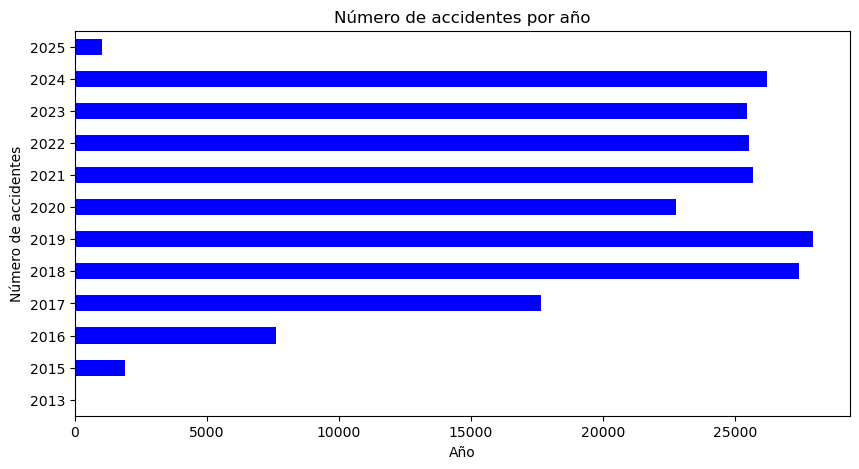

In [39]:
# Número de accidentes por año
accidents_per_year = df['crash_year'].value_counts().sort_index()
plt.figure(figsize=(10,5))
accidents_per_year.plot(kind='barh', color='b')
plt.xlabel('Año')
plt.ylabel('Número de accidentes')
plt.title('Número de accidentes por año')
plt.show()

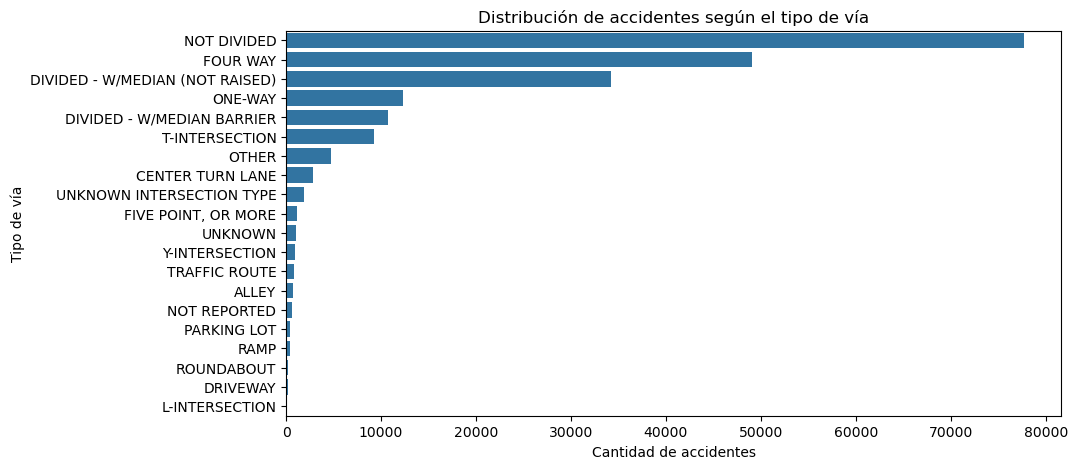

In [40]:
# Análisis de colisión por tipo de carretera
plt.figure(figsize=(10,5))
sns.countplot(y=df['trafficway_type'], order=df['trafficway_type'].value_counts().index)
plt.xlabel('Cantidad de accidentes')
plt.ylabel('Tipo de vía')
plt.title('Distribución de accidentes según el tipo de vía')
plt.show()

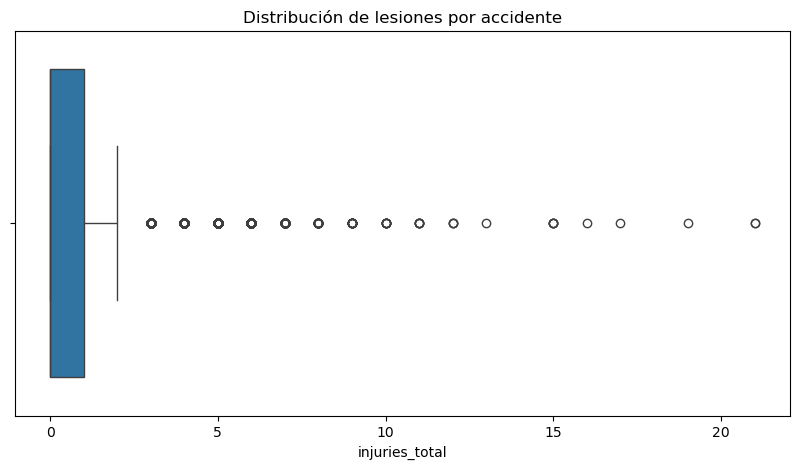

In [41]:
# Análisis de lesiones totales con diagramas de caja
plt.figure(figsize=(10,5))
sns.boxplot(x=df['injuries_total'])
plt.title('Distribución de lesiones por accidente')
plt.show()

## Paso 5: Prueba de hipótesis

**Hipótesis 1:** ¿Difieren las lesiones en función de las condiciones climáticas?
- **_H0_**: No hay diferencia en el número de lesiones entre condiciones climáticas.
- **_H1_**: Sí hay una diferencia en el número de lesiones según el clima.

In [42]:
clear_weather = df[df['weather_condition'] == 'CLEAR']['injuries_total'].dropna()
other_weather = df[df['weather_condition'] != 'CLEAR']['injuries_total'].dropna()

In [46]:
print("Diferencia varianza: ", clear_weather.var()-other_weather.var())

Diferencia varianza:  0.09953536265049168


In [45]:
from scipy.stats import levene

stat_levene, p_levene = levene(clear_weather, other_weather)

print("Estadístico de Levene:", stat_levene)
print("p-valor:", p_levene)
if p_levene < 0.05:
    print("Se rechaza H0: Las varianzas son diferentes")
else:
    print("No se puede rechazar H0: Las varianzas son iguales")

Estadístico de Levene: 71.48561183218682
p-valor: 2.8104478299833385e-17
Se rechaza H0: Las varianzas son diferentes


In [48]:
stat, p_value = ttest_ind(clear_weather, other_weather, equal_var=True)
print(f"Prueba de hipótesis entre condiciones climáticas: p-valor = {p_value:.5f}")

Prueba de hipótesis entre condiciones climáticas: p-valor = 0.00000


**Hipótesis 2:** ¿El número promedio de lesiones es significativamente mayor que 1?
- **_H0_**: El número promedio de lesiones es igual o menor a 1.
- **_H1_**: El número promedio de lesiones es mayor a 1.

In [21]:
stat, p_value = ttest_1samp(df['injuries_total'].dropna(), 1)
print(f"Prueba de hipótesis sobre el promedio de lesiones: p-valor = {p_value:.5f}")

Prueba de hipótesis sobre el promedio de lesiones: p-valor = 0.00000


**Hipótesis 3:** Correlación entre la hora del accidente y número de lesiones
- **_H0_**: No hay correlación entre la hora del accidente y el número de lesiones.
- **_H1_**: Existe correlación entre la hora del accidente y el número de lesiones.

In [22]:
if 'injuries_total' in df.columns and 'crash_hour' in df.columns:
    corr_coeff, p_corr = pearsonr(df['crash_hour'].dropna(), df['injuries_total'].dropna())
    print(f"Correlación entre hora del accidente y lesiones: coeficiente = {corr_coeff:.3f}, p-valor = {p_corr:.5f}")

Correlación entre hora del accidente y lesiones: coeficiente = -0.015, p-valor = 0.00000


## Paso 6: Conclusión general

**Conclusión:** Se realizó una exploración exhaustiva de los datos, incluyendo validaciones, limpieza, visualización y pruebas de hipótesis para obtener información útil sobre los accidentes de tráfico.